In [2]:
import h5py
import numpy as np
import os

# ---------------------------------
# Meep frequency units:
#   f_meep [1/µm] × c0 [µm/fs] → THz
#   c0 ≈ 0.299792458 µm/fs → THz conversion factor
C0_UM_PER_FS = 299.792458  # speed of light in µm/fs (= THz conversion)

def load_flux_data(h5_file):
    """Load frequency + flux spectra from Meep HDF5 file."""
    with h5py.File(h5_file, "r") as f:
        freq_meep = f["frequency"][:]   # Meep units: 1/µm
        flux_bus = f["flux_bus"][:]
        flux_drop = f["flux_drop"][:]
    return freq_meep, flux_bus, flux_drop


def convert_and_save(h5_file, out_folder=None):
    """
    Read flux_data.h5, convert to npy files matching the analysis code.

    Produces:
        freqs_thz.npy
        flux_bus.npy
        flux_drop.npy
    """
    if out_folder is None:
        out_folder = os.path.dirname(h5_file)
    os.makedirs(out_folder, exist_ok=True)

    # Load raw data
    freq_meep, flux_bus, flux_drop = load_flux_data(h5_file)

    # Convert frequencies → THz
    freqs_thz = freq_meep * C0_UM_PER_FS
    
    # Save npy files
    np.save(os.path.join(out_folder, "freqs_thz.npy"), freqs_thz)
    np.save(os.path.join(out_folder, "flux_bus.npy"), flux_bus)
    np.save(os.path.join(out_folder, "flux_drop.npy"), flux_drop)

    print(f"Saved converted files to: {out_folder}")


# ---------------------------------
# Example usage
if __name__ == "__main__":
    h5_path = "data/20251126_1802_sim_norm_r3.5_g0.02_f320_res48_decay0.0005/flux_data.h5"
    convert_and_save(h5_path)


Saved converted files to: data/20251126_1802_sim_norm_r3.5_g0.02_f320_res48_decay0.0005


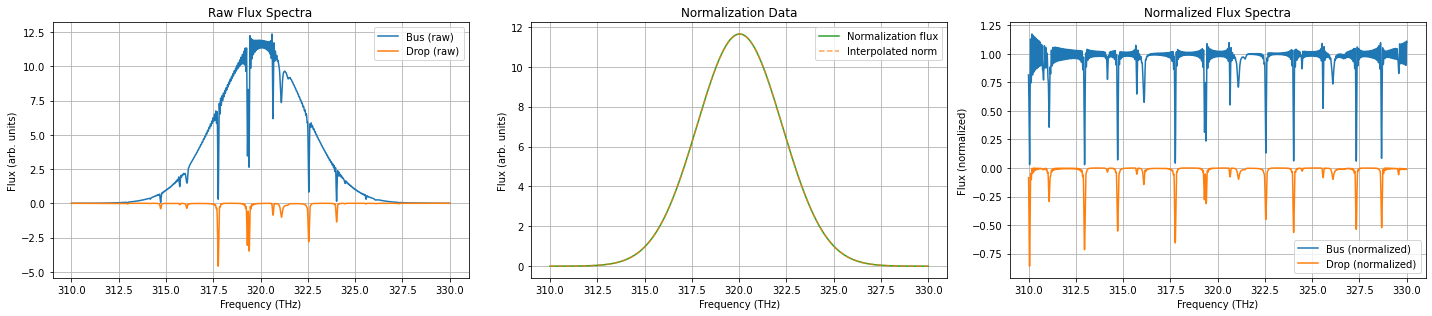

In [5]:
import matplotlib.pyplot as plt

# load raw data (load_flux_data, C0_UM_PER_FS and h5_path are defined in a previous cell)
freq_meep, flux_bus, flux_drop = load_flux_data(h5_path)

# convert frequency to THz
freqs_thz = freq_meep * C0_UM_PER_FS

# Check for normalization data
out_folder = os.path.dirname(h5_path)
norm_flux_path = os.path.join(out_folder, "norm_flux.npy")
norm_freqs_path = os.path.join(out_folder, "norm_freqs.npy")

if os.path.exists(norm_flux_path) and os.path.exists(norm_freqs_path):
    norm_flux = np.load(norm_flux_path)
    norm_freqs_meep = np.load(norm_freqs_path)
    # Convert normalization frequencies to THz
    norm_freqs = norm_freqs_meep * C0_UM_PER_FS
    # Interpolate normalization to match data frequencies
    norm_flux_interp = np.interp(freqs_thz, norm_freqs, norm_flux)
    flux_bus_norm = flux_bus / norm_flux_interp
    flux_drop_norm = flux_drop / norm_flux_interp
    has_norm = True
else:
    has_norm = False

# plot
fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))

# Left: Raw data
axes[0].plot(freqs_thz, flux_bus, label="Bus (raw)", linewidth=1.5)
axes[0].plot(freqs_thz, flux_drop, label="Drop (raw)", linewidth=1.5)
axes[0].set_xlabel("Frequency (THz)")
axes[0].set_ylabel("Flux (arb. units)")
axes[0].set_title("Raw Flux Spectra")
axes[0].legend()
axes[0].grid(True)

# Middle: Normalization data (if available)
if has_norm:
    axes[1].plot(norm_freqs, norm_flux, label="Normalization flux", linewidth=1.5, color='tab:green')
    axes[1].plot(freqs_thz, norm_flux_interp, '--', label="Interpolated norm", linewidth=1.5, color='tab:orange', alpha=0.7)
    axes[1].set_xlabel("Frequency (THz)")
    axes[1].set_ylabel("Flux (arb. units)")
    axes[1].set_title("Normalization Data")
    axes[1].legend()
    axes[1].grid(True)
else:
    axes[1].text(0.5, 0.5, "No normalization data found", 
             ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title("Normalization Data (unavailable)")

# Right: Normalized data (if available)
if has_norm:
    axes[2].plot(freqs_thz, flux_bus_norm, label="Bus (normalized)", linewidth=1.5)
    axes[2].plot(freqs_thz, flux_drop_norm, label="Drop (normalized)", linewidth=1.5)
    axes[2].set_xlabel("Frequency (THz)")
    axes[2].set_ylabel("Flux (normalized)")
    axes[2].set_title("Normalized Flux Spectra")
    axes[2].legend()
    axes[2].grid(True)
else:
    axes[2].text(0.5, 0.5, "No normalization data found", 
             ha='center', va='center', transform=axes[2].transAxes, fontsize=12)
    axes[2].set_title("Normalized Flux Spectra (unavailable)")

plt.tight_layout()
plt.show()